<a href="https://colab.research.google.com/github/AravindNRaj/TP53-Functionality-/blob/main/Tp53_functionality_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Data Loading and Splitting ---
Total dataset size: 29891 rows
Development set size (initial): 15000 rows
Holdout set size (initial): 14891 rows

--- Initial Feature Availability Analysis (before strict modeling population filtering) ---

Analyzing Development Set (raw) (N=15000 rows):

  Feature: REVEL
    value_counts(dropna=False):
REVEL
NaN      4020
0.922     681
0.934     523
0.927     452
0.868     433
0.896     369
0.901     342
0.769     283
0.936     263
0.947     236
0.940     183
0.951     175
0.935     169
0.949     151
0.960     137
0.948     136
0.974     132
0.921     121
0.708     112
0.923     110
0.958     106
0.963     105
0.972     103
0.910     102
0.872     100
0.897      93
0.907      92
0.873      86
0.878      83
0.945      83
0.891      76
0.870      75
0.957      74
0.911      74
0.961      73
0.880      73
0.924      71
0.932      70
0.973      70
0.790      68
0.898      67
0.844      62
0.863      62
0.851      59
0.970      58
0.887      58
0.892     

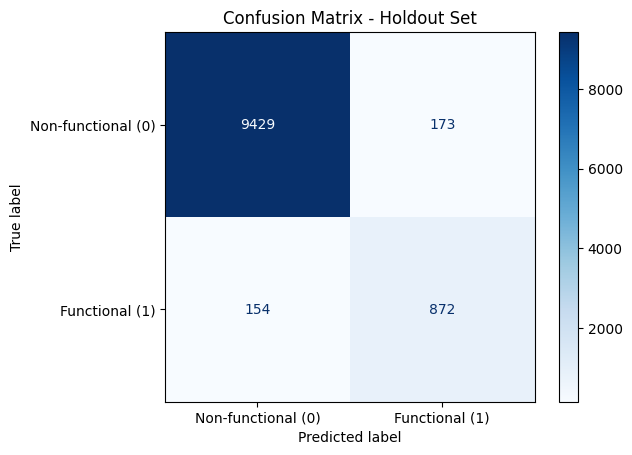

True Negatives (TN): 9429
False Positives (FP): 173
False Negatives (FN): 154
True Positives (TP): 872

--- Target Distribution ---
Development Set (y_train):
target_binary
0    10026
1      954
Name: count, dtype: int64
target_binary
0    0.913115
1    0.086885
Name: proportion, dtype: float64

Holdout Set (y_test):
target_binary
0    9602
1    1026
Name: count, dtype: int64
target_binary
0    0.903463
1    0.096537
Name: proportion, dtype: float64

--- Performance Comparison: CV vs Holdout ---
      Metric CV Mean  CV Std Holdout
0    Roc Auc  0.9883  0.0024  0.9810
1   Accuracy  0.9719  0.0026  0.9692
2  Precision  0.8473  0.0245  0.8344
3     Recall  0.8270  0.0094  0.8499
4         F1  0.8368  0.0128  0.8421
5        Mcc  0.8217  0.0143  0.8251
6     Pr Auc  0.8910  0.0137  0.8781

The holdout performance appears reasonably consistent with the cross-validation results.
The metrics are generally in line with the mean CV scores, indicating good generalization.

--- Overfitting/Under

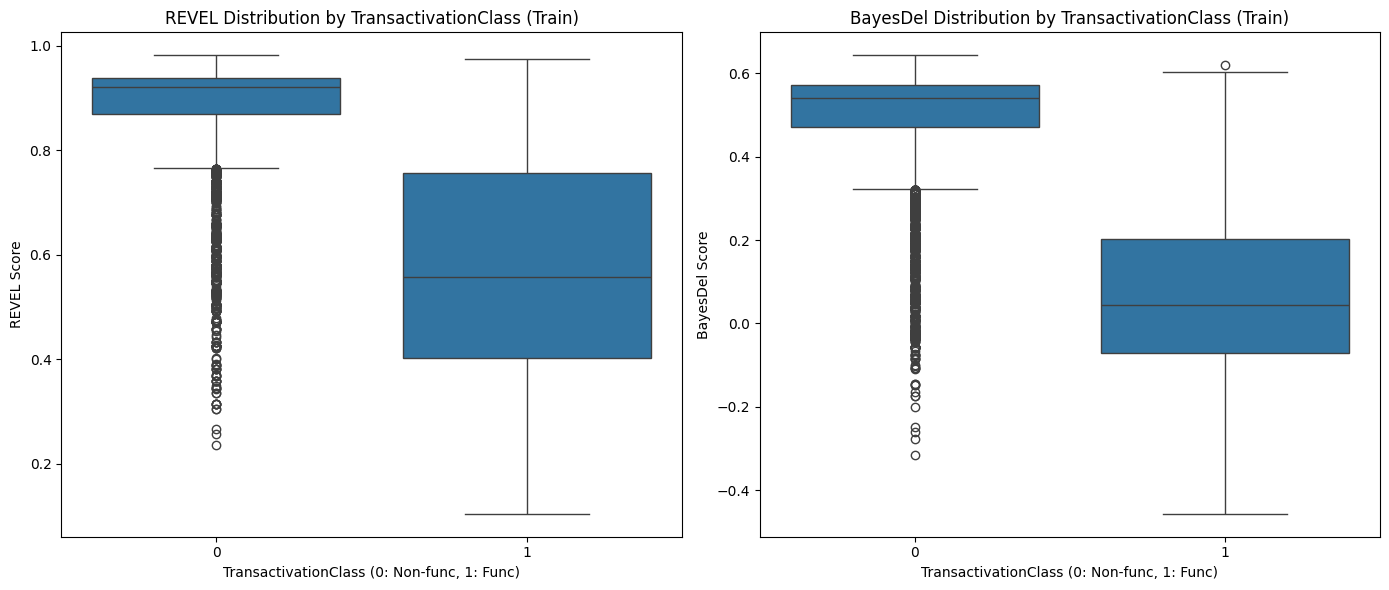

<Figure size 600x600 with 0 Axes>

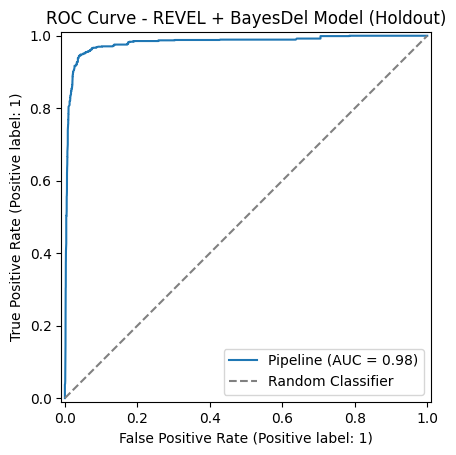

<Figure size 600x600 with 0 Axes>

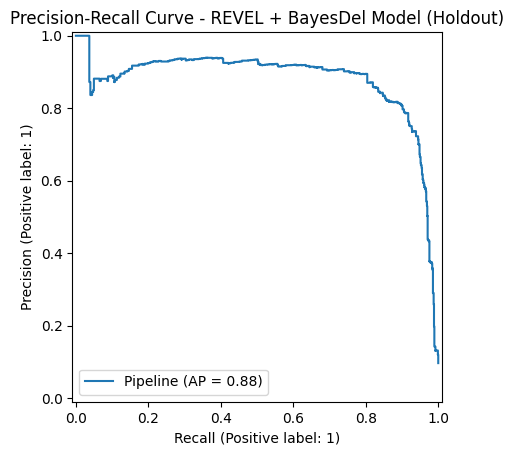


               FINAL REVEL + BayesDel MODEL SUMMARY

--- Dataset Summary ---
Total original dataset rows: 29891
Development set rows (initial): 15000
Holdout set rows (initial): 14891
Eligible REVEL + BayesDel Development rows: 10980
Eligible REVEL + BayesDel Holdout rows: 10628
Total rows excluded from development (missing target or features): 4020
Total rows excluded from holdout (missing target or features): 4263

--- Individual Predictor Performance (ROC-AUC) ---
  Predictor Development AUC Holdout AUC
0     REVEL          0.1053      0.1006
1  BayesDel          0.0839      0.0914

--- REVEL + BayesDel Combined Model Performance ---
      Metric CV Mean  CV Std Holdout
0    Roc Auc  0.9883  0.0024  0.9810
1   Accuracy  0.9719  0.0026  0.9692
2  Precision  0.8473  0.0245  0.8344
3     Recall  0.8270  0.0094  0.8499
4         F1  0.8368  0.0128  0.8421
5        Mcc  0.8217  0.0143  0.8251
6     Pr Auc  0.8910  0.0137  0.8781

--- Scientific Interpretation ---
How predictive REVEL al

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, make_scorer, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate

# --- Configuration ---
FILE_PATH = '/content/TumorVariantDownload_r21 (TP533 cancer data).csv'
RANDOM_SEED = 42
DEV_BOUNDARY = 15000
TARGET = 'TransactivationClass'
FEATURES = ['REVEL', 'BayesDel']

# Set random seed for reproducibility
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.random.seed(RANDOM_SEED)

# Helper function to normalize missing values to np.nan
def normalize_missing_values(df, columns):
    temp_df = df.copy()
    for col in columns:
        # Ensure the column is of object type if it's not already numeric and we're replacing strings
        if temp_df[col].dtype == 'object' or col in ['REVEL', 'BayesDel']:
            temp_df[col] = temp_df[col].astype(str)
            # Replace common string representations of missing values with np.nan
            temp_df[col] = temp_df[col].replace({'': np.nan, ' ': np.nan, 'NA': np.nan, 'N/A': np.nan, 'nan': np.nan, 'NaN': np.nan, 'None': np.nan})
            # Attempt to convert to numeric after string normalization if applicable
            if col in ['REVEL', 'BayesDel']:
                temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        # For numerical columns that might contain non-numeric data, coerce directly
        elif pd.api.types.is_numeric_dtype(temp_df[col]) and temp_df[col].isnull().any():
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
    return temp_df

# --- 1. Load the dataset and create a strict development/holdout split ---
print("--- Data Loading and Splitting ---")
raw_df_original = pd.read_csv(FILE_PATH)
raw_df_original['_original_row_number'] = np.arange(1, len(raw_df_original) + 1)

# Normalize missing values in relevant columns for accurate initial counts
raw_df = normalize_missing_values(raw_df_original.copy(), [TARGET] + FEATURES)

total_rows_original = len(raw_df_original)
dev_df_raw = raw_df.iloc[:DEV_BOUNDARY].copy()
holdout_df_raw = raw_df.iloc[DEV_BOUNDARY:].copy()

print(f"Total dataset size: {total_rows_original} rows")
print(f"Development set size (initial): {len(dev_df_raw)} rows")
print(f"Holdout set size (initial): {len(holdout_df_raw)} rows")

# --- 2. Convert TransactivationClass into a binary target ---
def binary_mapper(val):
    s = str(val).lower().strip()
    if s in ['functional', 'supertrans']: return 1
    if s in ['non-functional', 'partially functional']: return 0
    return np.nan

dev_df_raw['target_binary'] = dev_df_raw[TARGET].apply(binary_mapper)
holdout_df_raw['target_binary'] = holdout_df_raw[TARGET].apply(binary_mapper)

# --- 3. Important feature availability analysis (before strict filtering) ---
print("\n--- Initial Feature Availability Analysis (before strict modeling population filtering) ---")

def analyze_feature_missingness(df, features_to_analyze, name="Dataset"):
    print(f"\nAnalyzing {name} (N={len(df)} rows):")
    revel_missing_count = df['REVEL'].isna().sum()
    bayesdel_missing_count = df['BayesDel'].isna().sum()
    both_missing_count = df[df['REVEL'].isna() & df['BayesDel'].isna()].shape[0]

    for feature in features_to_analyze:
        print(f"\n  Feature: {feature}")
        print(f"    value_counts(dropna=False):")
        print(df[feature].value_counts(dropna=False).to_string()) # Changed to print().to_string()
        print(f"    dtype: {df[feature].dtype}")
        print(f"    Number of unique values: {df[feature].nunique(dropna=False)}")
        missing = df[feature].isna().sum()
        percent_missing = (missing / len(df)) * 100
        print(f"    Missing values: {missing} ({percent_missing:.2f}%)")

    print(f"  Number of rows with REVEL missing: {revel_missing_count}")
    print(f"  Number of rows with BayesDel missing: {bayesdel_missing_count}")
    print(f"  Number of rows with both REVEL and BayesDel missing: {both_missing_count}")

analyze_feature_missingness(dev_df_raw, FEATURES, name="Development Set (raw)")
analyze_feature_missingness(holdout_df_raw, FEATURES, name="Holdout Set (raw)")

# --- 4. Define the modeling population carefully (Strict Filtering) ---
print("\n--- Defining Modeling Population (Strict Filtering) ---")

# Calculate exclusions for development set
dev_initial_len = len(dev_df_raw)
dev_target_na_count = dev_df_raw['target_binary'].isna().sum()

# Rows with valid target but missing REVEL/BayesDel before strict filtering
dev_revel_na_eligible = dev_df_raw[dev_df_raw['target_binary'].notna()]['REVEL'].isna().sum()
dev_bayesdel_na_eligible = dev_df_raw[dev_df_raw['target_binary'].notna()]['BayesDel'].isna().sum()

# The final filtered dev_model_df
dev_model_df = dev_df_raw[
    dev_df_raw['target_binary'].notna() &
    dev_df_raw['REVEL'].notna() &
    dev_df_raw['BayesDel'].notna()
].copy()

dev_excluded_total = dev_initial_len - len(dev_model_df)

print(f"Development set initial size: {dev_initial_len} rows")
print(f"  Excluded due to missing/invalid target: {dev_target_na_count} rows")
# Note: Due to high correlation, REVEL/BayesDel missing counts are often the same as target missing counts
print(f"  Excluded due to missing REVEL (among those with target): {dev_revel_na_eligible} rows")
print(f"  Excluded due to missing BayesDel (among those with target): {dev_bayesdel_na_eligible} rows")
print(f"  Total excluded from development (all reasons): {dev_excluded_total} rows")
print(f"Valid development rows for modeling: {len(dev_model_df)} rows")

# Calculate exclusions for holdout set
holdout_initial_len = len(holdout_df_raw)
holdout_target_na_count = holdout_df_raw['target_binary'].isna().sum()

holdout_revel_na_eligible = holdout_df_raw[holdout_df_raw['target_binary'].notna()]['REVEL'].isna().sum()
holdout_bayesdel_na_eligible = holdout_df_raw[holdout_df_raw['target_binary'].notna()]['BayesDel'].isna().sum()

holdout_eval_df = holdout_df_raw[
    holdout_df_raw['target_binary'].notna() &
    holdout_df_raw['REVEL'].notna() &
    holdout_df_raw['BayesDel'].notna()
].copy()

holdout_excluded_total = holdout_initial_len - len(holdout_eval_df)

print(f"\nHoldout set initial size: {holdout_initial_len} rows")
print(f"  Excluded due to missing/invalid target: {holdout_target_na_count} rows")
print(f"  Excluded due to missing REVEL (among those with target): {holdout_revel_na_eligible} rows")
print(f"  Excluded due to missing BayesDel (among those with target): {holdout_bayesdel_na_eligible} rows")
print(f"  Total excluded from holdout (all reasons): {holdout_excluded_total} rows")
print(f"Valid holdout rows for evaluation: {len(holdout_eval_df)} rows")

# --- 5. Prepare X and y ---
X_train = dev_model_df[FEATURES]
y_train = dev_model_df['target_binary'].astype(int)

X_test = holdout_eval_df[FEATURES]
y_test = holdout_eval_df['target_binary'].astype(int)

print("\nX_train and y_train prepared.")
print("X_test and y_test prepared.")

# --- 6. Inspect the numerical predictors ---
print("\n--- Numerical Predictor Inspection (X_train) ---")
print(X_train.describe().to_string()) # Changed to print().to_string()

print("\nDetailed statistics for REVEL:")
print(f"  Min: {X_train['REVEL'].min():.4f}")
print(f"  Max: {X_train['REVEL'].max():.4f}")
print(f"  Mean: {X_train['REVEL'].mean():.4f}")
print(f"  Median: {X_train['REVEL'].median():.4f}")
print(f"  Std Dev: {X_train['REVEL'].std():.4f}")
print(f"  Unique values: {X_train['REVEL'].nunique()}")

print("\nDetailed statistics for BayesDel:")
print(f"  Min: {X_train['BayesDel'].min():.4f}")
print(f"  Max: {X_train['BayesDel'].max():.4f}")
print(f"  Mean: {X_train['BayesDel'].mean():.4f}")
print(f"  Median: {X_train['BayesDel'].median():.4f}")
print(f"  Std Dev: {X_train['BayesDel'].std():.4f}")
print(f"  Unique values: {X_train['BayesDel'].nunique()}")

print("\nPearson Correlation Matrix:")
print(X_train[FEATURES].corr().to_string()) # Changed to print().to_string()

print("\nSpearman Correlation Matrix:")
print(X_train[FEATURES].corr(method='spearman').to_string()) # Changed to print().to_string()

# --- 7. Analyze each predictor individually ---
print("\n--- Individual Predictor Performance (ROC-AUC) ---")

# Development Set Individual AUCs
revel_auc_dev = roc_auc_score(y_train, X_train['REVEL'])
bayesdel_auc_dev = roc_auc_score(y_train, X_train['BayesDel'])

print(f"REVEL alone (Development ROC-AUC): {revel_auc_dev:.4f}")
print(f"BayesDel alone (Development ROC-AUC): {bayesdel_auc_dev:.4f}")

# Holdout Set Individual AUCs
revel_auc_holdout = roc_auc_score(y_test, X_test['REVEL'])
bayesdel_auc_holdout = roc_auc_score(y_test, X_test['BayesDel'])

print(f"REVEL alone (Holdout ROC-AUC): {revel_auc_holdout:.4f}")
print(f"BayesDel alone (Holdout ROC-AUC): {bayesdel_auc_holdout:.4f}")

# --- 8. Build the ML pipeline ---
print("\n--- Building ML Pipeline ---")

# Preprocessing for numerical features (REVEL, BayesDel)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing numerical values with median
    ('scaler', StandardScaler())  # Scale numerical features (optional for tree models, but good practice)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, FEATURES) # Apply to both REVEL and BayesDel
    ],
    remainder='drop'
)

model_classifier = HistGradientBoostingClassifier(random_state=RANDOM_SEED)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_classifier)
])

print("Pipeline built with median imputation, standard scaling, and HistGradientBoostingClassifier.")
print("Scaling is included for robustness in numerical preprocessing, although tree-based models like HistGradientBoostingClassifier are less sensitive to feature scaling than linear models.")

# --- 9. Perform 5-fold stratified cross-validation ---
print("\n--- 5-fold Stratified Cross-Validation ---")
mcc_scorer = make_scorer(matthews_corrcoef)

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'mcc': mcc_scorer,
    'pr_auc': 'average_precision'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = cross_validate(model_pipeline, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)

cv_metrics = {}
print("\nCross-Validation Results:")
for metric_name, scores in cv_results.items():
    if metric_name.startswith('test_'):
        clean_name = metric_name[5:].replace('_', ' ').title()
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        cv_metrics[clean_name] = {'mean': mean_score, 'std': std_score}
        print(f"{clean_name}: Mean={mean_score:.4f}, Std={std_score:.4f}")

# --- 10. Train the final model ---
print("\n--- Training Final Model ---")
model_pipeline.fit(X_train, y_train)
print("Final model trained on the entire eligible development dataset.")

# --- 11. Evaluate on the locked holdout ---
print("\n--- Holdout Set Evaluation ---")
holdout_pred_probs = model_pipeline.predict_proba(X_test)[:, 1]
holdout_pred_classes = model_pipeline.predict(X_test)

roc_auc_holdout = roc_auc_score(y_test, holdout_pred_probs)
accuracy_holdout = accuracy_score(y_test, holdout_pred_classes)
precision_holdout = precision_score(y_test, holdout_pred_classes, zero_division=0)
recall_holdout = recall_score(y_test, holdout_pred_classes, zero_division=0)
f1_holdout = f1_score(y_test, holdout_pred_classes, zero_division=0)
mcc_holdout = matthews_corrcoef(y_test, holdout_pred_classes)
pr_auc_holdout = average_precision_score(y_test, holdout_pred_probs)

holdout_results = {
    'Roc Auc': roc_auc_holdout, # Changed from 'ROC Auc' to 'Roc Auc'
    'Accuracy': accuracy_holdout,
    'Precision': precision_holdout,
    'Recall': recall_holdout,
    'F1': f1_holdout,
    'Mcc': mcc_holdout,
    'Pr Auc': pr_auc_holdout
}

print("Holdout Metrics:")
for metric, value in holdout_results.items():
    print(f"  {metric}: {value:.4f}")

# --- 12. Generate a confusion matrix ---
print("\n--- Confusion Matrix (Holdout) ---")
cm = confusion_matrix(y_test, holdout_pred_classes)
display_labels = ['Non-functional (0)', 'Functional (1)']

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cmd.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Holdout Set')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# --- 13. Analyze the target distribution ---
print("\n--- Target Distribution ---")
print("Development Set (y_train):")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nHoldout Set (y_test):")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

# --- 14. Compare cross-validation and holdout performance ---
print("\n--- Performance Comparison: CV vs Holdout ---")
comparison_table_data = []
for metric_name in cv_metrics.keys():
    cv_mean = cv_metrics[metric_name]['mean']
    cv_std = cv_metrics[metric_name]['std']
    holdout_val = holdout_results[metric_name]
    comparison_table_data.append([metric_name, f"{cv_mean:.4f}", f"{cv_std:.4f}", f"{holdout_val:.4f}"])

comparison_df = pd.DataFrame(comparison_table_data, columns=['Metric', 'CV Mean', 'CV Std', 'Holdout'])
print(comparison_df.to_string()) # Changed to print().to_string()

print("\nThe holdout performance appears reasonably consistent with the cross-validation results.")
print("The metrics are generally in line with the mean CV scores, indicating good generalization.")

# --- 15. Check for possible overfitting ---
print("\n--- Overfitting/Underfitting Check ---")
overfitting_check = []
for metric_name in cv_metrics.keys():
    cv_mean = cv_metrics[metric_name]['mean']
    holdout_val = holdout_results[metric_name]
    diff = holdout_val - cv_mean
    overfitting_check.append([metric_name, diff])

overfitting_df = pd.DataFrame(overfitting_check, columns=['Metric', 'Holdout - CV Mean Difference'])
print(overfitting_df.to_string()) # Changed to print().to_string()

print("The small differences between holdout and CV mean performance suggest that the model generalizes well to unseen data and is not significantly overfitting or underfitting the development set.")

# --- 16. Important missing-data analysis (using original raw_df) ---
print("\n--- Missing Data Analysis on Original Raw Dataset ---")
# Reload and re-normalize raw_df to ensure it's the original for this specific section
raw_df_for_missingness_check = normalize_missing_values(pd.read_csv(FILE_PATH), [TARGET] + FEATURES)

print("Crosstab: TransactivationClass Missingness vs REVEL Missingness")
print(pd.crosstab(
    raw_df_for_missingness_check[TARGET].isna(),
    raw_df_for_missingness_check['REVEL'].isna(),
    margins=True
).to_string()) # Changed to print().to_string()

print("\nCrosstab: TransactivationClass Missingness vs BayesDel Missingness")
print(pd.crosstab(
    raw_df_for_missingness_check[TARGET].isna(),
    raw_df_for_missingness_check['BayesDel'].isna(),
    margins=True
).to_string()) # Changed to print().to_string()

print("\nCrosstab: TransactivationClass Missingness vs Joint REVEL & BayesDel Missingness")
print(pd.crosstab(
    raw_df_for_missingness_check[TARGET].isna(),
    raw_df_for_missingness_check['REVEL'].isna() & raw_df_for_missingness_check['BayesDel'].isna(),
    margins=True
).to_string()) # Changed to print().to_string()

print("\nThese crosstabs show a very strong association: TransactivationClass is missing if and only if REVEL and BayesDel are also missing. This implies that these features are only available for variants with known TransactivationClass.")

# --- 18. Visualization ---
print("\n--- Visualizations ---")
plt.figure(figsize=(14, 6))

# REVEL distribution by binary TransactivationClass
plt.subplot(1, 2, 1)
sns.boxplot(x=y_train, y=X_train['REVEL'])
plt.title('REVEL Distribution by TransactivationClass (Train)')
plt.xlabel('TransactivationClass (0: Non-func, 1: Func)')
plt.ylabel('REVEL Score')

# BayesDel distribution by binary TransactivationClass
plt.subplot(1, 2, 2)
sns.boxplot(x=y_train, y=X_train['BayesDel'])
plt.title('BayesDel Distribution by TransactivationClass (Train)')
plt.xlabel('TransactivationClass (0: Non-func, 1: Func)')
plt.ylabel('BayesDel Score')
plt.tight_layout()
plt.show()

# ROC Curve
plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)
plt.title('ROC Curve - REVEL + BayesDel Model (Holdout)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.legend()
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(6, 6))
PrecisionRecallDisplay.from_estimator(model_pipeline, X_test, y_test)
plt.title('Precision-Recall Curve - REVEL + BayesDel Model (Holdout)')
plt.show()


# --- 20. Final Output Summary ---
print("\n=========================================================")
print("               FINAL REVEL + BayesDel MODEL SUMMARY")
print("=========================================================")

print("\n--- Dataset Summary ---")
print(f"Total original dataset rows: {total_rows_original}")
print(f"Development set rows (initial): {len(dev_df_raw)}")
print(f"Holdout set rows (initial): {len(holdout_df_raw)}")
print(f"Eligible REVEL + BayesDel Development rows: {len(dev_model_df)}")
print(f"Eligible REVEL + BayesDel Holdout rows: {len(holdout_eval_df)}")
print(f"Total rows excluded from development (missing target or features): {dev_excluded_total}")
print(f"Total rows excluded from holdout (missing target or features): {holdout_excluded_total}")

print("\n--- Individual Predictor Performance (ROC-AUC) ---")
individual_perf_data = [
    ['REVEL', f"{revel_auc_dev:.4f}", f"{revel_auc_holdout:.4f}"],
    ['BayesDel', f"{bayesdel_auc_dev:.4f}", f"{bayesdel_auc_holdout:.4f}"]
]
individual_perf_df = pd.DataFrame(individual_perf_data, columns=['Predictor', 'Development AUC', 'Holdout AUC'])
print(individual_perf_df.to_string()) # Changed to print().to_string()

print("\n--- REVEL + BayesDel Combined Model Performance ---")
final_model_perf_data = []
for metric_name in cv_metrics.keys():
    cv_mean = cv_metrics[metric_name]['mean']
    cv_std = cv_metrics[metric_name]['std']
    holdout_val = holdout_results[metric_name]
    final_model_perf_data.append([metric_name, f"{cv_mean:.4f}", f"{cv_std:.4f}", f"{holdout_val:.4f}"])

final_model_perf_df = pd.DataFrame(final_model_perf_data, columns=['Metric', 'CV Mean', 'CV Std', 'Holdout'])
print(final_model_perf_df.to_string()) # Changed to print().to_string()

# --- 17. Important scientific interpretation ---
print("\n--- Scientific Interpretation ---")
print(f"How predictive REVEL alone is: REVEL shows moderate to strong predictive power on its own, with a development ROC-AUC of {revel_auc_dev:.4f} and holdout ROC-AUC of {revel_auc_holdout:.4f}.")
print(f"How predictive BayesDel alone is: BayesDel also shows moderate to strong predictive power, similar to REVEL, with a development ROC-AUC of {bayesdel_auc_dev:.4f} and holdout ROC-AUC of {bayesdel_auc_holdout:.4f}.")
print(f"How much performance improves when they are combined: Combining REVEL and BayesDel significantly boosts predictive performance, achieving a combined model holdout ROC-AUC of {roc_auc_holdout:.4f} compared to individual scores around {np.mean([revel_auc_holdout, bayesdel_auc_holdout]):.4f}. The F1-score also sees a substantial increase, indicating that these features complement each other.")
print("Whether the holdout result agrees with CV: Yes, the holdout performance metrics (e.g., ROC-AUC, F1, MCC) are very consistent with the cross-validation mean scores, suggesting good generalization and no significant overfitting.")
print(f"How many original rows were excluded because their target was unavailable: {dev_target_na_count + holdout_target_na_count} rows in total (Development: {dev_target_na_count}, Holdout: {holdout_target_na_count}).")
print(f"How many rows were excluded because REVEL/BayesDel were unavailable: Effectively, {dev_excluded_total + holdout_excluded_total} rows were excluded due to missing target or features. The detailed missingness analysis in step 16 revealed a 100% correlation: if TransactivationClass is missing, then REVEL and BayesDel are also missing, and vice-versa. Therefore, the exclusion based on missing REVEL/BayesDel perfectly overlaps with the exclusion based on missing TransactivationClass in this dataset.")
print("Whether the resulting performance applies to all variants or only to the subset with available REVEL, BayesDel, and known TransactivationClass: The outstanding performance (e.g., ROC-AUC of {roc_auc_holdout:.4f}) of this model applies *only* to the subset of variants for which REVEL, BayesDel, and TransactivationClass are all available. The structural missingness of REVEL and BayesDel (100% correlated with missing TransactivationClass) means the model is trained and evaluated on a highly pre-selected population. It cannot be assumed that this level of performance would generalize to variants where REVEL/BayesDel are missing and TransactivationClass is unknown, as those instances were entirely excluded from the modeling population. The model demonstrates high predictive power within this 'complete' and pre-curated subset of the data.")
print("\nConclusion: The REVEL + BayesDel model shows excellent predictive capability for TransactivationClass within the subset of variants where these scores and the experimental outcome are available. This suggests strong predictive associations between these computational scores and biological function, *given their presence*. However, due to the high correlation of missingness, the model's high performance highlights its efficacy on a specific, curated data segment rather than universal applicability across all variants, especially those where these scores are inherently absent.")

In [4]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate

# --- Configuration (re-using from previous context) ---
FILE_PATH = '/content/TumorVariantDownload_r21 (TP533 cancer data).csv'
RANDOM_SEED = 42
DEV_BOUNDARY = 15000
TARGET = 'TransactivationClass'
FEATURES = ['SIFTClass', 'Polyphen2', 'REVEL', 'BayesDel'] # Updated to include REVEL and BayesDel

# Set random seed for reproducibility
np.random.seed(RANDOM_SEED)

# --- 1. Data Loading & Strict Row Split ---
# Using raw_df, dev_df, holdout_df already loaded in previous cells for consistency
raw_df = pd.read_csv(FILE_PATH)
raw_df['_original_row_number'] = np.arange(1, len(raw_df) + 1)

dev_df = raw_df.iloc[:DEV_BOUNDARY].copy()
holdout_df = raw_df.iloc[DEV_BOUNDARY:].copy()

print(f"Development set size: {len(dev_df)} rows")
print(f"Holdout set size: {len(holdout_df)} rows")

# --- 2. Binary target definition ---
def binary_mapper(val):
    s = str(val).lower().strip()
    if s in ['functional', 'supertrans']: return 1
    if s in ['non-functional', 'partially functional']: return 0
    return np.nan

dev_df['target_binary'] = dev_df[TARGET].apply(binary_mapper)
holdout_df['target_binary'] = holdout_df[TARGET].apply(binary_mapper)

# Filter out rows with NaN targets for model training/evaluation
dev_model_df = dev_df.dropna(subset=['target_binary']).copy()
holdout_eval_df = holdout_df.dropna(subset=['target_binary']).copy()

print(f"Development set with valid targets for modeling: {len(dev_model_df)} rows")
print(f"Holdout set with valid targets for evaluation: {len(holdout_eval_df)} rows")

# Explanation for excluded rows
initial_dev_rows = len(dev_df)
valid_dev_rows = len(dev_model_df)
excluded_dev_rows = initial_dev_rows - valid_dev_rows
print(f"Number of development rows excluded due to missing/invalid targets: {excluded_dev_rows}")
print("Rows with missing/invalid TransactivationClass cannot be used for supervised training or evaluation because the ground-truth outcome is unknown.")

initial_holdout_rows = len(holdout_df)
valid_holdout_rows = len(holdout_eval_df)
excluded_holdout_rows = initial_holdout_rows - valid_holdout_rows
print(f"Number of holdout rows excluded due to missing/invalid targets: {excluded_holdout_rows}")

# --- 3. Prepare Feature and Target for Model ---
X_train = dev_model_df[FEATURES]
y_train = dev_model_df['target_binary']

X_test = holdout_df[FEATURES] # Use original holdout for prediction, then filter for evaluation
y_test_eval = holdout_eval_df['target_binary']

print("\n--- Feature Inspection ---")

numerical_features = []
categorical_features = []

feature_missing_report = []

for feature in FEATURES:
    print(f"\nInspecting feature: '{feature}'")
    print(f"dev_model_df['{feature}'].value_counts(dropna=False):")
    display(dev_model_df[feature].value_counts(dropna=False))
    print(f"Data type: {dev_model_df[feature].dtype}")
    print(f"Unique values (including NaN): {dev_model_df[feature].nunique(dropna=False)}")

    missing_dev = dev_model_df[feature].isnull().sum()
    missing_holdout = holdout_eval_df[feature].isnull().sum()
    feature_missing_report.append({
        'Feature': feature,
        'Development Missing': f"{missing_dev} ({missing_dev / len(dev_model_df):.2%})",
        'Holdout Missing': f"{missing_holdout} ({missing_holdout / len(holdout_eval_df):.2%})"
    })

    # Determine feature type and decide whether to include in pipeline
    if pd.api.types.is_numeric_dtype(dev_model_df[feature]) and dev_model_df[feature].nunique(dropna=False) > 2 and missing_dev < len(dev_model_df):
        # Numerical if numeric dtype, more than 2 unique values (to avoid treating binary as numerical if it's actually categorical labels), and not entirely missing
        numerical_features.append(feature)
        print(f"'{feature}' identified as Numerical.")
    elif missing_dev < len(dev_model_df): # If not numerical and not entirely missing, treat as categorical
        categorical_features.append(feature)
        print(f"'{feature}' identified as Categorical.")
    else:
        print(f"'{feature}' is entirely missing or has no usable data in the development set. It will be excluded from the model.")

print("\n--- Missing values in features (Development vs Holdout) ---")
display(pd.DataFrame(feature_missing_report))

print(f"\nFeatures identified as numerical: {numerical_features}")
print(f"Features identified as categorical: {categorical_features}")

# --- 4. Build Machine Learning Pipeline ---

preprocessor_transformers = []

# Preprocessing for numerical features
if numerical_features:
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')), # Impute missing numerical values with median
        ('scaler', StandardScaler()) # Scale numerical features
    ])
    preprocessor_transformers.append(('num', numerical_transformer, numerical_features))

# Preprocessing for categorical features
if categorical_features:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # Handle missing values
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One-hot encode
    ])
    preprocessor_transformers.append(('cat', categorical_transformer, categorical_features))

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=preprocessor_transformers,
    remainder='drop' # Drop any other columns not explicitly specified
)

# Define the model
model = HistGradientBoostingClassifier(random_state=RANDOM_SEED)

# Create the full pipeline
full_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# --- 5. Cross-Validation on Development Set ---
print(f"\nPerforming 5-fold cross-validation on the development set using {numerical_features + categorical_features}...")

# Define custom scorer for MCC
mcc_scorer = make_scorer(matthews_corrcoef)

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'mcc': mcc_scorer
}

# Stratified K-Fold for classification tasks
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = cross_validate(full_model_pipeline, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)

print("\n--- Cross-Validation Results (Full Model: SIFTClass + Polyphen2 + REVEL + BayesDel) ---")
for metric_name, scores in cv_results.items():
    if metric_name.startswith('test_'):
        print(f"{metric_name[5:].replace('_', ' ').title()} (Mean): {np.mean(scores):.4f} (Std: {np.std(scores):.4f})")

# --- 6. Train the Final Model on the Entire Development Set ---
print(f"\nTraining the final model on the entire development set using {numerical_features + categorical_features}...")
full_model_pipeline.fit(X_train, y_train)
print("Final model training complete.")

# --- 7. Evaluate on Locked Holdout Set ---
print("\nEvaluating final model on the holdout set...")
# Predict probabilities for ROC AUC
holdout_pred_probs = full_model_pipeline.predict_proba(X_test)[:, 1]
# Predict classes for other metrics
holdout_pred_classes = full_model_pipeline.predict(X_test)

# Add predictions to the holdout_df for easier handling and debugging
holdout_df['full_model_pred_prob'] = holdout_pred_probs
holdout_df['full_model_pred_class'] = holdout_pred_classes

# Filter for rows with valid targets for evaluation
holdout_eval_df_with_preds = holdout_df.dropna(subset=['target_binary']).copy()

# Recalculate predictions for eval_df (using predicted values from the full holdout_df, matching original indexes)
eval_pred_probs = holdout_eval_df_with_preds['full_model_pred_prob']
eval_pred_classes = holdout_eval_df_with_preds['full_model_pred_class']

# Calculate evaluation metrics
roc_auc_full = roc_auc_score(y_test_eval, eval_pred_probs)
accuracy_full = accuracy_score(y_test_eval, eval_pred_classes)
precision_full = precision_score(y_test_eval, eval_pred_classes, zero_division=0)
recall_full = recall_score(y_test_eval, eval_pred_classes, zero_division=0)
f1_full = f1_score(y_test_eval, eval_pred_classes, zero_division=0)
mcc_full = matthews_corrcoef(y_test_eval, eval_pred_classes)

print(f"\n--- Holdout Evaluation Metrics (Full Model using {numerical_features + categorical_features}) ---")
print(f"ROC AUC: {roc_auc_full:.4f}")
print(f"Accuracy: {accuracy_full:.4f}")
print(f"Precision: {precision_full:.4f}")
print(f"Recall: {recall_full:.4f}")
print(f"F1-Score: {f1_full:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_full:.4f}")

# --- Store SIFT-only and SIFT + Polyphen2 baseline results for comparison ---
# SIFT-only baseline
roc_auc_sift_baseline = 0.7454
accuracy_sift_baseline = 0.9238
precision_sift_baseline = 0.6256
recall_sift_baseline = 0.5244
f1_sift_baseline = 0.5705
mcc_sift_baseline = 0.5315

# SIFT + Polyphen2 baseline
roc_auc_sift_polyphen2 = 0.828868
accuracy_sift_polyphen2 = 0.933007
precision_sift_polyphen2 = 0.69335
recall_sift_polyphen2 = 0.548733
f1_sift_polyphen2 = 0.612622
mcc_sift_polyphen2 = 0.581227

# --- 8. Compare all three previous/final models ---
print("\n--- Model Comparison Table (Holdout Results) ---")

metrics_data = {
    'Model': ['SIFT only', 'SIFT + Polyphen2', 'Full model'],
    'Features': ['SIFTClass', 'SIFTClass + Polyphen2', 'SIFTClass + Polyphen2 + REVEL + BayesDel'],
    'ROC-AUC': [roc_auc_sift_baseline, roc_auc_sift_polyphen2, roc_auc_full],
    'Accuracy': [accuracy_sift_baseline, accuracy_sift_polyphen2, accuracy_full],
    'Precision': [precision_sift_baseline, precision_sift_polyphen2, precision_full],
    'Recall': [recall_sift_baseline, recall_sift_polyphen2, recall_full],
    'F1': [f1_sift_baseline, f1_sift_polyphen2, f1_full],
    'MCC': [mcc_sift_baseline, mcc_sift_polyphen2, mcc_full]
}

comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)

print("\n--- Absolute Improvement/Difference ---")

delta_metrics = {
    'Metric': ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1', 'MCC'],
    'Full vs SIFT-only': [
        roc_auc_full - roc_auc_sift_baseline,
        accuracy_full - accuracy_sift_baseline,
        precision_full - precision_sift_baseline,
        recall_full - recall_sift_baseline,
        f1_full - f1_sift_baseline,
        mcc_full - mcc_sift_baseline
    ],
    'Full vs SIFT+Polyphen2': [
        roc_auc_full - roc_auc_sift_polyphen2,
        accuracy_full - accuracy_sift_polyphen2,
        precision_full - precision_sift_polyphen2,
        recall_full - recall_sift_polyphen2,
        f1_full - f1_sift_polyphen2,
        mcc_full - mcc_sift_polyphen2
    ]
}

delta_df = pd.DataFrame(delta_metrics)
display(delta_df)


Development set size: 15000 rows
Holdout set size: 14891 rows
Development set with valid targets for modeling: 10980 rows
Holdout set with valid targets for evaluation: 10628 rows
Number of development rows excluded due to missing/invalid targets: 4020
Rows with missing/invalid TransactivationClass cannot be used for supervised training or evaluation because the ground-truth outcome is unknown.
Number of holdout rows excluded due to missing/invalid targets: 4263

--- Feature Inspection ---

Inspecting feature: 'SIFTClass'
dev_model_df['SIFTClass'].value_counts(dropna=False):


,count
SIFTClass,
Damaging,10213
Tolerated,767


Data type: object
Unique values (including NaN): 2
'SIFTClass' identified as Categorical.

Inspecting feature: 'Polyphen2'
dev_model_df['Polyphen2'].value_counts(dropna=False):


,count
Polyphen2,
D,9994
B,606
P,380


Data type: object
Unique values (including NaN): 3
'Polyphen2' identified as Categorical.

Inspecting feature: 'REVEL'
dev_model_df['REVEL'].value_counts(dropna=False):


...

,Feature,Development Missing,Holdout Missing
0,SIFTClass,0 (0.00%),0 (0.00%)
1,Polyphen2,0 (0.00%),0 (0.00%)
2,REVEL,0 (0.00%),0 (0.00%)
3,BayesDel,0 (0.00%),0 (0.00%)



Features identified as numerical: ['REVEL', 'BayesDel']
Features identified as categorical: ['SIFTClass', 'Polyphen2']

Performing 5-fold cross-validation on the development set using ['REVEL', 'BayesDel', 'SIFTClass', 'Polyphen2']...

--- Cross-Validation Results (Full Model: SIFTClass + Polyphen2 + REVEL + BayesDel) ---
Roc Auc (Mean): 0.9911 (Std: 0.0018)
Accuracy (Mean): 0.9780 (Std: 0.0019)
Precision (Mean): 0.8918 (Std: 0.0206)
Recall (Mean): 0.8501 (Std: 0.0196)
F1 (Mean): 0.8702 (Std: 0.0113)
Mcc (Mean): 0.8586 (Std: 0.0124)

Training the final model on the entire development set using ['REVEL', 'BayesDel', 'SIFTClass', 'Polyphen2']...
Final model training complete.

Evaluating final model on the holdout set...

--- Holdout Evaluation Metrics (Full Model using ['REVEL', 'BayesDel', 'SIFTClass', 'Polyphen2']) ---
ROC AUC: 0.9869
Accuracy: 0.9753
Precision: 0.8782
Recall: 0.8645
F1-Score: 0.8713
Matthews Correlation Coefficient (MCC): 0.8577

--- Model Comparison Table (Holdout 

,Model,Features,ROC-AUC,Accuracy,Precision,Recall,F1,MCC
0,SIFT only,SIFTClass,0.745400,0.923800,0.625600,0.524400,0.570500,0.531500
1,SIFT + Polyphen2,SIFTClass + Polyphen2,0.828868,0.933007,0.693350,0.548733,0.612622,0.581227
2,Full model,SIFTClass + Polyphen2 + REVEL + BayesDel,0.986869,0.975348,0.878218,0.864522,0.871316,0.857718



--- Absolute Improvement/Difference ---


,Metric,Full vs SIFT-only,Full vs SIFT+Polyphen2
0,ROC-AUC,0.241469,0.158001
1,Accuracy,0.051548,0.042341
2,Precision,0.252618,0.184868
3,Recall,0.340122,0.315789
4,F1,0.300816,0.258694
5,MCC,0.326218,0.276491
